In [1]:
import duckdb
import contextily as cx
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

from advan_test import data
from advan_test.utils import project_root

# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

con = duckdb.connect()
con.install_extension("spatial")
con.load_extension("spatial")

In [2]:
ROOT = project_root()
DATA_PATH = ROOT / "data"
PARQUET_DIR_PATH = DATA_PATH / "2025-weekly-patterns-plus"
DATA_GLOB = PARQUET_DIR_PATH / "*.parquet"
CSV_PATH = DATA_PATH / "weekly-patterns-plus-sample.csv"
US_PATH = DATA_PATH / "us-states.json"

In [3]:
con.execute(f"""
    CREATE OR REPLACE TABLE states AS
    SELECT * FROM ST_Read('{US_PATH}')
""")

In [4]:
lf = con.sql(f"""
    WITH boundary AS (
        SELECT geom
        FROM states 
        WHERE name = 'Arizona'
    ), t AS (
        SELECT *
        FROM '{DATA_GLOB}'
    )
    SELECT t.*
    FROM t, boundary
    WHERE ST_Within(
        ST_Point(t.LONGITUDE, t.LATITUDE),
        boundary.geom
    )
""").pl().lazy()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [5]:
lf.head().collect()

BRAND,BUCKETED_DWELL_TIMES,CITY,CLOSE_DATE,DATE_RANGE_END,DATE_RANGE_START,DEVICE_TYPE,DISTANCE_FROM_HOME,FOOTPRINT_ID,ID_STORE,ISO_COUNTRY_CODE,IS_DISTRIBUTOR,LATITUDE,LOCATION_NAME,LONGITUDE,MEDIAN_DWELL,MSA_CODE,NAICS_CODE,OPEN_DATE,PERSISTENT_ID,PERSISTENT_ID_STORE,POI_CBG,POSTAL_CODE,REGION,RELATED_SAME_DAY_BRAND,RELATED_SAME_WEEK_BRAND,STREET_ADDRESS,SUB_CATEGORY,TICKER,TOP_CATEGORY,VISITOR_COUNTRY_OF_ORIGIN,VISITOR_COUNTS,VISITOR_DAYTIME_CBGS,VISITOR_HOME_AGGREGATION,VISITOR_HOME_CBGS,VISITS_BY_DAY,VISITS_BY_EACH_HOUR,VISIT_COUNTS
str,str,str,date,datetime[μs],datetime[μs],str,f64,"decimal[38,0]",str,str,bool,f64,str,f64,f64,"decimal[38,0]",str,date,str,str,str,str,str,str,str,str,str,str,str,str,"decimal[38,0]",str,str,str,str,str,"decimal[38,0]"
"""Full-Service Restaurants""","""{""<5"":0, ""5-20"":0, ""21-60"":0,""…","""Tucson""",2038-01-01,2025-01-12 00:00:00,2025-01-06 00:00:00,"""{""android"":107}""",32016.0,7670432343683343973,"""9028800""","""US""",false,32.108799,"""Full-Service Restaurants""",-110.784889,363.0,46060,"""722511""",1970-01-01,"""A1_NAICS-722511""","""9028800""","""040190040731""","""85747""","""AZ""","""{""Freshpet"":107,""Mall"":107,""Sa…","""{""Big O Tires"":107,""Freshpet"":…","""7885 S Danforth Ave""","""Full-Service Restaurants ""","""NAICS-722511""","""Restaurants and Other Eating P…",null,107,"""{""040190041261"":107}""","""{""04019004126"":107}""","""{""040190041261"":107}""","""[12,12,12,24,12,12,71]""","""[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0…",154
"""Convenience Stores""","""{""<5"":1423, ""5-20"":126, ""21-60…","""Phoenix""",2038-01-01,2025-01-12 00:00:00,2025-01-06 00:00:00,"""{""ios"":1020,""android"":425}""",12977.0,8468670776074192084,"""7752731""","""US""",false,33.79916,"""Convenience Stores""",-112.066208,4.0,38060,"""445120""",1970-01-01,"""A1_NAICS-445120""","""7752731""","""040136105002""","""85085""","""AZ""","""{""Gas Stations"":1445,""Mall"":12…","""{""Gas Stations"":1445,""Mall"":14…","""620 E Carefree Hwy""","""Convenience Stores ""","""NAICS-445120""","""Grocery Stores ""","""{""US"":1445}""",1445,"""{""040136105003"":176,""040136105…","""{""04013610700"":474,""0401361050…","""{""040136107003"":189,""040136105…","""[307,189,177,212,248,71,357]""","""[13,0,0,13,13,0,0,77,13,26,26,…",1562
"""Full-Service Restaurants""",null,"""Peoria""",2038-01-01,2025-01-12 00:00:00,2025-01-06 00:00:00,null,null,8239786758723219817,"""9028778""","""US""",false,33.7118,"""Full-Service Restaurants""",-112.277199,82.0,38060,"""722511""",1970-01-01,"""A1_NAICS-722511""","""9028778""","""040136109021""","""85383""","""AZ""","""{""Airport"":166,""Armstrong Floo…","""{""Airport"":166,""Armstrong Floo…","""25811 N 101St Ave""","""Full-Service Restaurants ""","""NAICS-722511""","""Restaurants and Other Eating P…",null,166,null,null,null,"""[59,59,59,83,83,71,59]""",null,473
"""New Car Dealers""","""{""<5"":984, ""5-20"":0, ""21-60"":0…","""Gilbert""",2038-01-01,2025-01-12 00:00:00,2025-01-06 00:00:00,"""{""ios"":843,""android"":140}""",8348.0,8281497279302557219,"""10461459""","""US""",false,33.321546,"""New Car Dealers""",-111.772002,1.0,38060,"""441110""",1970-01-01,"""A1_NAICS-441110""","""10461459""","""040138145003""","""85296""","""AZ""","""{""Mall"":889,""Western Union"":60…","""{""Mall"":983,""Freshpet"":936,""We…","""851 E Liberty Ln""","""New Car Dealers ""","""NAICS-441110""","""Automobile Dealers ""","""{""US"":983}""",983,"""{""040138150003"":281,""040139805…","""{""04013815000"":983}""","""{""040138150003"":392,""040139411…","""[106,0,0,165,272,0,440]""","""[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0…",984
"""Convenience Stores""","""{""<5"":1101, ""5-20"":0, ""21-60"":…","""Mesa""",2038-01-01,2025-01-12 00:00:00,2025-01-06 00:00:00,"""{""android"":1090}""",10271.0,8084456027564659774,"""11987529""","""US""",false,33.378246,null,-111.860499,3.0,38060,"""447110""",1970-01-01,"""A1_CONV-A""","""11987529""","""040134222221""","""85202-5855""","""AZ""","""{""Mall"":894,""Convenience Store…","""{""Mall"":1

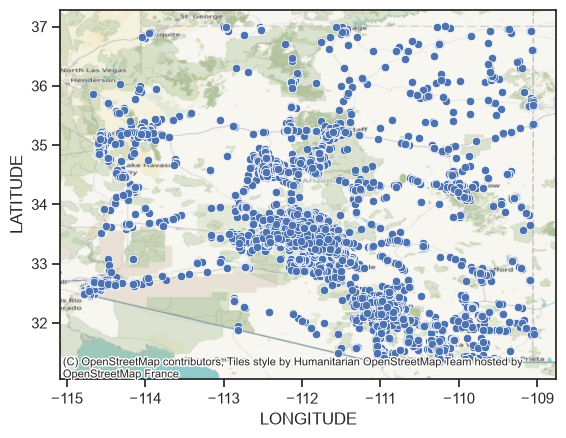

In [6]:
pois = lf.select("BRAND", "LONGITUDE", "LATITUDE").unique().collect()
ax = sns.scatterplot(pois, x="LONGITUDE", y="LATITUDE")
cx.add_basemap(ax, crs="EPSG:4326")